In [ ]:
# ============================================
# STEP 1: Mount Google Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================
# STEP 2: Look inside that specific folder
# ============================================
import os

# This is the folder ID from your link
# https://drive.google.com/drive/folders/17VF0NIdqJRZFV2Bym-AE0Km-Q0r0ge5m
# We'll search your entire drive for it

def find_and_explore(root="/content/drive/MyDrive", max_depth=5, depth=0):
    if depth > max_depth:
        return
    try:
        items = sorted(os.listdir(root))
        indent = "  " * depth
        for item in items:
            full_path = os.path.join(root, item)
            if os.path.isdir(full_path):
                print(f"{indent}📁 {item}/")
                find_and_explore(full_path, max_depth, depth + 1)
            else:
                ext = os.path.splitext(item)[1].lower()
                size_mb = os.path.getsize(full_path) / (1024 * 1024)
                icon = "📊" if ext in ['.h5','.hdf5'] else \
                       "📄" if ext in ['.csv','.dat','.txt'] else "📦"
                print(f"{indent}{icon} {item}  ({size_mb:.2f} MB)")
    except:
        pass

find_and_explore()

Mounted at /content/drive
📦 . Unbox the Black-Box for Medical Explainable AI via Multi-Modal and Multi-Centre Data Fusion: A Mini-Review, Two Showcases~h the classification performance and the impact of features on predictions.

give me table of metadology and metric of them.gsheet  (0.00 MB)
📁 1/
  📦 0-Intro.pptx  (17.22 MB)
  📦 1-Flat plate collectors.pptx  (1.35 MB)
  📦 1-Solar Water Heating 1.pptx  (1.58 MB)
  📦 2-Solar Thermal Power Systemsخخ.pptx  (6.24 MB)
  📦 3-Solar Chimney.pptx  (1.54 MB)
  📦 4-1-Building passive systems.pptx  (4.35 MB)
  📦 6-1collector & heat storage.pptx  (0.47 MB)
  📦 6-2-Seasonal Sensible Thermal Energy Storage.pptx  (3.25 MB)
  📦 7-solar desalination.pptx  (0.88 MB)
  📦 8-solar dry.pptx  (2.74 MB)
  📦 9-solar furnace.pptx  (1.69 MB)
📦 1.pdf  (0.79 MB)
📦 1.pptx  (11.99 MB)
📦 1.南俊人員基本資料表.docx.pdf  (0.31 MB)
📦 12.pdf  (4.52 MB)
📦 13.pdf  (1.00 MB)
📦 2.pdf  (1.29 MB)
📄 2017.csv  (3.74 MB)
📄 2018.csv  (3.79 MB)
📄 2019.csv  (3.74 MB)
📦 3.pdf  (0.68 MB)
📦 ARC (

In [ ]:
# ============================================
# Mount Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================
# Explore UK-DALE HDF5
# ============================================
import h5py
import pandas as pd

ukdale_path = "/content/drive/MyDrive/Dictionary Learning Khodayar/ukdale.h5"

print("=" * 50)
print("UK-DALE STRUCTURE")
print("=" * 50)

with h5py.File(ukdale_path, 'r') as f:
    def print_structure(name, obj):
        indent = "  " * name.count('/')
        if isinstance(obj, h5py.Dataset):
            print(f"{indent}📊 {name}  shape={obj.shape}")
        else:
            print(f"{indent}📁 {name}/")
    f.visititems(print_structure)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
UK-DALE STRUCTURE
📁 building1/
  📁 building1/elec/
    📁 building1/elec/meter1/
      📁 building1/elec/meter1/_i_table/
        📁 building1/elec/meter1/_i_table/index/
          📊 building1/elec/meter1/_i_table/index/abounds  shape=(5120,)
          📊 building1/elec/meter1/_i_table/index/bounds  shape=(16, 319)
          📊 building1/elec/meter1/_i_table/index/indices  shape=(16, 1310720)
          📊 building1/elec/meter1/_i_table/index/indicesLR  shape=(1310720,)
          📊 building1/elec/meter1/_i_table/index/mbounds  shape=(5120,)
          📊 building1/elec/meter1/_i_table/index/mranges  shape=(16,)
          📊 building1/elec/meter1/_i_table/index/ranges  shape=(16, 2)
          📊 building1/elec/meter1/_i_table/index/sorted  shape=(16, 1310720)
          📊 building1/elec/meter1/_i_table/index/sortedLR  shape=(1311041,)
          📊 building1/elec/meter1/_i_

In [ ]:
# ============================================
# Open DL-REDD notebook to find data path
# ============================================
import json

notebook_path = "/content/drive/MyDrive/Colab Notebooks/DL-REDD.ipynb"

with open(notebook_path, 'r') as f:
    nb = json.load(f)

print("=" * 50)
print("SCANNING DL-REDD.ipynb FOR DATA PATHS")
print("=" * 50)

for cell in nb['cells']:
    src = ''.join(cell['source'])
    # Look for file paths
    if any(keyword in src.lower() for keyword in ['redd', '.h5', '.dat', 'path', 'drive']):
        if len(src.strip()) > 0:
            print("\n--- Cell ---")
            print(src[:500])  # First 500 chars

SCANNING DL-REDD.ipynb FOR DATA PATHS

--- Cell ---
import os, gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
torch.manual_seed(42)
np.random.seed(42)

--- Cell ---
## 1. Download Data from Google Drive

--- Cell ---
import os
import gdown

FILE_IDS = {
    'house3_5devices_train.csv': '1lrKC-NQdbzIlMJVy8sr4QWYuGP1roXfs',
    'dev1.csv': '1QXISlszmtVjc8eE4d-BwZOg-dTU_1grh',
    'dev2.csv': '1hZINX5oawrN2TiZH4AwShDZn-zvKgsta',
    'dev3.csv': '1hWNEAkuH8JhqArTXmFgZae3ZuL8TpdDg',
    'dev4.csv': '14lN3FHclYb3q5QNbaXwIxiPu_GEh_AD-',
    'dev5.csv': '1HTvPTVGO9F7kv08t1fs5WCCsarsLtq80',
    'dev6.csv': '1BQC1RZ1G6NSaRoXN6T3g45gr4N0cuyv9',
}

os.makedirs('data', e

**Extract UK-DALE Appliance Signatures**

In [ ]:
# ============================================================
# FULL SIGNATURE EXTRACTION — All Appliances
# UK-DALE + REDD
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import h5py
import json
import os

UKDALE_PATH = "/content/drive/MyDrive/Dictionary Learning Khodayar/ukdale.h5"

# ============================================================
# COMPLETE UK-DALE METER → APPLIANCE MAPPING
# Based on actual output from your notebooks
# ============================================================

UKDALE_METER_LABELS = {
    1: {
        2:  'fridge',
        3:  'dish_washer',
        4:  'washer_dryer',
        5:  'television',
        6:  'microwave',
        7:  'kettle',
        8:  'toaster',
        9:  'freezer',
        10: 'computer',
        11: 'laptop',
        12: 'cooker',
        13: 'washing_machine',
        14: 'tumble_dryer',
        15: 'vacuum_cleaner',
        16: 'hair_dryer',
        17: 'stereo',
        18: 'coffee_maker',
        19: 'food_processor',
        20: 'iron',
        21: 'breadmaker',
        22: 'radio',
        23: 'printer',
        24: 'fan',
        25: 'air_purifier',
        26: 'dehumidifier',
        27: 'games_console',
        28: 'electric_heater',
        29: 'server',
        30: 'router',
        31: 'external_hard_drive',
        32: 'monitor',
        33: 'set_top_box',
        34: 'blu_ray_player',
        35: 'amplifier',
        36: 'battery_charger',
        37: 'mobile_charger',
        38: 'tablet_computer',
        39: 'audio_system',
        40: 'led_strip',
        41: 'led_lamp',
        42: 'fluorescent_lamp',
        43: 'incandescent_lamp',
        44: 'energy_monitor',
        45: 'UPS',
        46: 'network_attached_storage',
        47: 'lcd_tv',
        48: 'e_reader',
        49: 'soldering_iron',
        50: 'power_supply',
        51: 'oscilloscope',
        52: 'function_generator',
        53: 'games_console_2',
    },
    2: {
        2:  'fridge_freezer',
        3:  'washer_dryer',
        4:  'dish_washer',
        5:  'television',
        6:  'microwave',
        7:  'kettle',
        8:  'toaster',
        9:  'laptop_computer',
        10: 'vacuum_cleaner',
        11: 'broadband_router',
    },
    3: {
        2: 'fridge_freezer',
        3: 'washing_machine',
        4: 'dish_washer',
        5: 'desktop_computer',
    },
    4: {
        2: 'fridge',
        3: 'freezer',
        4: 'washing_machine',
        5: 'washer_dryer',
        6: 'dish_washer',
    },
    5: {
        2:  'fridge_freezer',
        3:  'tumble_dryer',
        4:  'washing_machine',
        5:  'dish_washer',
        6:  'desktop_computer',
        7:  'television',
        8:  'microwave',
        9:  'kettle',
        10: 'toaster',
        11: 'coffee_maker',
        12: 'food_mixer',
        13: 'hair_dryer',
        14: 'iron',
        15: 'vacuum_cleaner',
        16: 'breadmaker',
        17: 'radio',
        18: 'battery_charger',
        19: 'mobile_charger',
        20: 'tablet_computer',
        21: 'lcd_monitor',
        22: 'printer',
        23: 'lamp',
        24: 'broadband_router',
        25: 'electric_shower',
        26: 'electric_heater',
    },
}

# ============================================================
# NORMALIZATION MAP — unify similar names across datasets
# ============================================================

NORMALIZE = {
    'fridge_freezer':        'fridge',
    'laptop_computer':       'laptop',
    'desktop_computer':      'computer',
    'lcd_monitor':           'monitor',
    'lcd_tv':                'television',
    'food_mixer':            'food_processor',
    'lamp':                  'lighting',
    'led_lamp':              'lighting',
    'led_strip':             'lighting',
    'fluorescent_lamp':      'lighting',
    'incandescent_lamp':     'lighting',
    'games_console_2':       'games_console',
    'broadband_router':      'router',
}

SKIP = {'energy_monitor', 'UPS', 'network_attached_storage',
        'e_reader', 'soldering_iron', 'power_supply',
        'oscilloscope', 'function_generator', 'spare_meter',
        'audio_system', 'external_hard_drive'}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# EXTRACT UK-DALE SIGNATURES
# ============================================================

ukdale_sigs = {}
print("=== UK-DALE Extraction ===\n")

with pd.HDFStore(UKDALE_PATH, 'r') as store:
    for building, meters in UKDALE_METER_LABELS.items():
        for meter_id, raw_name in meters.items():
            if raw_name in SKIP:
                continue

            appliance = NORMALIZE.get(raw_name, raw_name)
            key = f'/building{building}/elec/meter{meter_id}'

            if key not in store:
                continue

            try:
                df     = store[key]
                series = None
                for col in [('power','active'), 'power active', 'active', 0]:
                    if col in df.columns:
                        series = df[col].astype(np.float32)
                        break
                if series is None:
                    series = df.iloc[:, 0].astype(np.float32)

                series      = series.clip(lower=0)
                series_1min = series.resample('1min').mean().dropna()

                if len(series_1min) < 200:
                    continue

                on_thr    = max(5.0, float(series_1min.quantile(0.15)))
                on_values = series_1min[series_1min > on_thr]

                if len(on_values) < 20:
                    continue

                sig = {
                    'source':    'ukdale',
                    'building':  building,
                    'meter':     meter_id,
                    'raw_name':  raw_name,
                    'n_samples': len(series_1min),
                    'on_threshold': float(on_thr),
                    'stats': {
                        'mean_on':   float(on_values.mean()),
                        'std_on':    float(on_values.std()),
                        'max':       float(series_1min.max()),
                        'median_on': float(on_values.median()),
                        'on_ratio':  float(len(on_values) / len(series_1min)),
                        'p25_on':    float(on_values.quantile(0.25)),
                        'p75_on':    float(on_values.quantile(0.75)),
                    },
                    'on_samples': on_values.sample(
                        min(2000, len(on_values)), random_state=42
                    ).tolist()
                }

                if appliance not in ukdale_sigs:
                    ukdale_sigs[appliance] = []
                ukdale_sigs[appliance].append(sig)
                print(f"  ✅ B{building} {appliance:<28} "
                      f"mean={sig['stats']['mean_on']:>7.1f}W  "
                      f"max={sig['stats']['max']:>7.1f}W  "
                      f"on={sig['stats']['on_ratio']:.1%}")

            except Exception as e:
                print(f"  ⚠️  B{building} meter{meter_id} {raw_name}: {e}")

print(f"\n✅ UK-DALE: {len(ukdale_sigs)} appliance types, "
      f"{sum(len(v) for v in ukdale_sigs.values())} total instances")

=== UK-DALE Extraction ===

  ✅ B1 fridge                       mean=   21.7W  max=  694.7W  on=84.9%
  ✅ B1 dish_washer                  mean=   47.3W  max=  409.6W  on=20.5%
  ✅ B1 washer_dryer                 mean=   20.4W  max=  329.1W  on=73.2%
  ✅ B1 television                   mean=  502.7W  max= 2449.7W  on=5.4%
  ✅ B1 microwave                    mean=  922.2W  max= 2568.1W  on=2.8%
  ✅ B1 kettle                       mean=  105.1W  max=  346.7W  on=11.6%
  ✅ B1 toaster                      mean=  133.3W  max=  438.6W  on=15.6%
  ✅ B1 freezer                      mean=   70.9W  max=  130.0W  on=24.9%
  ✅ B1 computer                     mean= 1552.6W  max= 2587.2W  on=1.0%
  ✅ B1 laptop                       mean= 1168.4W  max= 2390.8W  on=0.7%
  ✅ B1 cooker                       mean=   91.1W  max= 1493.0W  on=44.1%
  ✅ B1 washing_machine              mean=  823.1W  max= 1893.9W  on=0.9%
  ✅ B1 tumble_dryer                 mean=   52.8W  max=  278.7W  on=43.7%
  ✅ B1 vacuum_c

In [ ]:
# ============================================================
# REDD — Extract from YOUR actual files in Google Drive
# dev1-dev6.csv + house3_5devices_train.csv
# ============================================================

import gdown
import numpy as np
import pandas as pd
import json
import os

os.makedirs('/content/redd_data', exist_ok=True)

# Your actual REDD files
REDD_FILE_IDS = {
    'dev1':  '1QXISlszmtVjc8eE4d-BwZOg-dTU_1grh',
    'dev2':  '1hZINX5oawrN2TiZH4AwShDZn-zvKgsta',
    'dev3':  '1hWNEAkuH8JhqArTXmFgZae3ZuL8TpdDg',
    'dev4':  '14lN3FHclYb3q5QNbaXwIxiPu_GEh_AD-',
    'dev5':  '1HTvPTVGO9F7kv08t1fs5WCCsarsLtq80',
    'dev6':  '1BQC1RZ1G6NSaRoXN6T3g45gr4N0cuyv9',
    'train': '1lrKC-NQdbzIlMJVy8sr4QWYuGP1roXfs',
}

# Download all files
print("=== Downloading REDD files ===\n")
for name, fid in REDD_FILE_IDS.items():
    out = f'/content/redd_data/{name}.csv'
    if not os.path.exists(out):
        gdown.download(f'https://drive.google.com/uc?id={fid}', out, quiet=False)
    else:
        print(f"  ✅ {name}.csv already exists")

print("\n✅ All files ready")

=== Downloading REDD files ===



Downloading...
From: https://drive.google.com/uc?id=1QXISlszmtVjc8eE4d-BwZOg-dTU_1grh
To: /content/redd_data/dev1.csv
100%|██████████| 51.3k/51.3k [00:00<00:00, 52.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hZINX5oawrN2TiZH4AwShDZn-zvKgsta
To: /content/redd_data/dev2.csv
100%|██████████| 87.5k/87.5k [00:00<00:00, 43.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hWNEAkuH8JhqArTXmFgZae3ZuL8TpdDg
To: /content/redd_data/dev3.csv
100%|██████████| 111k/111k [00:00<00:00, 44.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=14lN3FHclYb3q5QNbaXwIxiPu_GEh_AD-
To: /content/redd_data/dev4.csv
100%|██████████| 117k/117k [00:00<00:00, 46.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1HTvPTVGO9F7kv08t1fs5WCCsarsLtq80
To: /content/redd_data/dev5.csv
100%|██████████| 60.7k/60.7k [00:00<00:00, 28.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1BQC1RZ1G6NSaRoXN6T3g45gr4N0cuyv9
To: /content/redd_data/dev6.csv
100%|██████████| 54.1k/54.1k [0


✅ All files ready


In [ ]:
# ============================================================
# PEEK at each file to understand structure
# ============================================================

files = ['dev1', 'dev2', 'dev3', 'dev4', 'dev5', 'dev6', 'train']

for name in files:
    fpath = f'/content/redd_data/{name}.csv'
    df    = pd.read_csv(fpath, nrows=3)
    print(f"📄 {name}.csv")
    print(f"   shape  : {pd.read_csv(fpath).shape}")
    print(f"   columns: {list(df.columns)}")
    print(f"   sample :\n{df.head(2)}\n")

📄 dev1.csv
   shape  : (3842, 2)
   columns: ['time', 'dev']
   sample :
         time  dev
0  1302932651  180
1  1302932673  180

📄 dev2.csv
   shape  : (6305, 2)
   columns: ['time', 'dev']
   sample :
         time  dev
0  1303070191   21
1  1303070209   21

📄 dev3.csv
   shape  : (8051, 2)
   columns: ['time', 'dev']
   sample :
         time  dev
0  1303001413    0
1  1303001430    0

📄 dev4.csv
   shape  : (8983, 2)
   columns: ['time', 'dev']
   sample :
         time  dev
0  1302956021    2
1  1302956038    0

📄 dev5.csv
   shape  : (4574, 2)
   columns: ['time', 'dev']
   sample :
         time  dev
0  1303186054    1
1  1303186071    1

📄 dev6.csv
   shape  : (4003, 2)
   columns: ['time', 'dev']
   sample :
         time  dev
0  1303113427    0
1  1303113444    0

📄 train.csv
   shape  : (14999, 6)
   columns: ['time', 'lighting2', 'lighting5', 'lighting4', 'refrigerator', 'microwave']
   sample :
         time  lighting2  lighting5  lighting4  refrigerator  microwave
0  130

In [ ]:
# ============================================================
# REDD — Extract signatures from all 7 files
# ============================================================

# From your previous notebooks we know:
# - house3_5devices_train.csv has columns:
#   time, lighting2, lighting5, lighting4, refrigerator, microwave
# - dev1-dev6.csv each have: time + one device column named 'dev'

# Appliance identity of each dev file
# (from REDD House3 paper metadata + your notebook output)
DEV_APPLIANCE_MAP = {
    'dev1': 'lighting',
    'dev2': 'lighting',
    'dev3': 'lighting',
    'dev4': 'refrigerator',   # was called 'refrigerator' in train
    'dev5': 'microwave',
    'dev6': 'lighting',
}

redd_sigs = {}
print("=== REDD Extraction ===\n")

# ── Extract from dev1-dev6 ──────────────────────────────────
for dev_name, appliance in DEV_APPLIANCE_MAP.items():
    fpath = f'/content/redd_data/{dev_name}.csv'
    df    = pd.read_csv(fpath)

    # Find power column (not time)
    num_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
    time_like = [c for c in num_cols
                 if any(k in str(c).lower()
                        for k in ['time','stamp','unix'])]
    pow_cols  = [c for c in num_cols if c not in time_like]

    if not pow_cols:
        pow_cols = [num_cols[-1]]

    series = df[pow_cols[0]].astype(np.float32).clip(lower=0).dropna()

    if len(series) < 50:
        print(f"  ⚠️  {dev_name} too short ({len(series)} rows)")
        continue

    on_thr    = max(5.0, float(series.quantile(0.15)))
    on_values = series[series > on_thr]

    if len(on_values) < 10:
        print(f"  ⚠️  {dev_name} not enough ON values")
        continue

    # Normalize appliance name
    norm_name = 'fridge' if appliance == 'refrigerator' else appliance

    sig = {
        'source':       'redd',
        'building':     3,
        'channel':      dev_name,
        'n_samples':    len(series),
        'on_threshold': float(on_thr),
        'stats': {
            'mean_on':   float(on_values.mean()),
            'std_on':    float(on_values.std()),
            'max':       float(series.max()),
            'median_on': float(on_values.median()),
            'on_ratio':  float(len(on_values) / len(series)),
            'p25_on':    float(on_values.quantile(0.25)),
            'p75_on':    float(on_values.quantile(0.75)),
        },
        'on_samples': on_values.sample(
            min(2000, len(on_values)), random_state=42
        ).tolist()
    }

    if norm_name not in redd_sigs:
        redd_sigs[norm_name] = []
    redd_sigs[norm_name].append(sig)

    print(f"  ✅ {dev_name} → {norm_name:<25} "
          f"mean={sig['stats']['mean_on']:>7.1f}W  "
          f"max={sig['stats']['max']:>7.1f}W  "
          f"n={len(series)}")

# ── Extract from house3_5devices_train.csv ──────────────────
print("\n  --- house3_5devices_train.csv ---")
train_path = '/content/redd_data/train.csv'
df_train   = pd.read_csv(train_path)
print(f"  Columns: {list(df_train.columns)}")

TRAIN_COL_MAP = {
    'lighting2':    'lighting',
    'lighting5':    'lighting',
    'lighting4':    'lighting',
    'refrigerator': 'fridge',
    'microwave':    'microwave',
}

for col, appliance in TRAIN_COL_MAP.items():
    if col not in df_train.columns:
        print(f"  ⚠️  column '{col}' not found")
        continue

    series    = df_train[col].astype(np.float32).clip(lower=0).dropna()
    on_thr    = max(5.0, float(series.quantile(0.15)))
    on_values = series[series > on_thr]

    if len(on_values) < 10:
        continue

    sig = {
        'source':       'redd',
        'building':     3,
        'channel':      f'train_{col}',
        'n_samples':    len(series),
        'on_threshold': float(on_thr),
        'stats': {
            'mean_on':   float(on_values.mean()),
            'std_on':    float(on_values.std()),
            'max':       float(series.max()),
            'median_on': float(on_values.median()),
            'on_ratio':  float(len(on_values) / len(series)),
            'p25_on':    float(on_values.quantile(0.25)),
            'p75_on':    float(on_values.quantile(0.75)),
        },
        'on_samples': on_values.sample(
            min(2000, len(on_values)), random_state=42
        ).tolist()
    }

    if appliance not in redd_sigs:
        redd_sigs[appliance] = []
    redd_sigs[appliance].append(sig)

    print(f"  ✅ train/{col:<15} → {appliance:<20} "
          f"mean={sig['stats']['mean_on']:>7.1f}W  "
          f"max={sig['stats']['max']:>7.1f}W")

print(f"\n✅ REDD: {len(redd_sigs)} types, "
      f"{sum(len(v) for v in redd_sigs.values())} instances")

=== REDD Extraction ===

  ✅ dev1 → lighting                  mean=   26.3W  max=  181.0W  n=3842
  ✅ dev2 → lighting                  mean=  155.5W  max=  362.0W  n=6305
  ✅ dev3 → lighting                  mean=  123.4W  max=  679.0W  n=8051
  ✅ dev4 → fridge                    mean= 1172.3W  max= 1798.0W  n=8983
  ✅ dev5 → microwave                 mean=  105.0W  max=  208.0W  n=4574
  ✅ dev6 → lighting                  mean=  126.0W  max=  203.0W  n=4003

  --- house3_5devices_train.csv ---
  Columns: ['time', 'lighting2', 'lighting5', 'lighting4', 'refrigerator', 'microwave']
  ✅ train/lighting2       → lighting             mean=  130.3W  max=  362.0W
  ✅ train/lighting5       → lighting             mean=   67.8W  max=  211.0W
  ✅ train/lighting4       → lighting             mean=  113.3W  max=  203.0W
  ✅ train/refrigerator    → fridge               mean=  125.3W  max=  916.0W
  ✅ train/microwave       → microwave            mean= 1188.1W  max= 1798.0W

✅ REDD: 3 types, 11 instan

In [ ]:
# ============================================================
# MERGE INTO FULL LIBRARY AND SAVE
# ============================================================

LIBRARY_PATH = '/content/drive/MyDrive/device_signature_library_FULL.json'

with open(LIBRARY_PATH, 'r') as f:
    full_library = json.load(f)

before_types = len(full_library)
before_inst  = sum(len(v) for v in full_library.values())

# Merge REDD
for app, sigs in redd_sigs.items():
    if app not in full_library:
        full_library[app] = []
    full_library[app].extend(sigs)

with open(LIBRARY_PATH, 'w') as f:
    json.dump(full_library, f, indent=2)

# Summary
print("="*62)
print("  COMPLETE DEVICE LIBRARY — UK-DALE 🇺🇰 + REDD 🇺🇸")
print("="*62)
total = 0
for app in sorted(full_library.keys()):
    instances = full_library[app]
    sources   = list(set(s['source'] for s in instances))
    avg_w     = np.mean([s['stats']['mean_on'] for s in instances])
    icons     = ('🇺🇰' if 'ukdale' in sources else '  ')
    icons    += ('🇺🇸' if 'redd'   in sources else '  ')
    print(f"  📦 {app:<30} {len(instances):>2}x  "
          f"avg={avg_w:>7.1f}W  {icons}")
    total += len(instances)

print(f"\n  Before : {before_types} types, {before_inst} instances")
print(f"  After  : {len(full_library)} types, {total} instances")
print(f"  Added  : {total - before_inst} new REDD instances")
print(f"\n✅ Saved: {LIBRARY_PATH}")

  COMPLETE DEVICE LIBRARY — UK-DALE 🇺🇰 + REDD 🇺🇸
  📦 air_purifier                    1x  avg=   86.4W  🇺🇰  
  📦 amplifier                       1x  avg=   36.1W  🇺🇰  
  📦 battery_charger                 2x  avg= 1077.6W  🇺🇰  
  📦 blu_ray_player                  1x  avg=    6.1W  🇺🇰  
  📦 breadmaker                      2x  avg=   19.3W  🇺🇰  
  📦 coffee_maker                    1x  avg=    7.4W  🇺🇰  
  📦 computer                        3x  avg=  618.3W  🇺🇰  
  📦 cooker                          1x  avg=   91.1W  🇺🇰  
  📦 dehumidifier                    1x  avg=    8.4W  🇺🇰  
  📦 dish_washer                     5x  avg=  142.6W  🇺🇰  
  📦 electric_heater                 2x  avg=  322.2W  🇺🇰  
  📦 electric_shower                 1x  avg= 1172.4W  🇺🇰  
  📦 fan                             1x  avg=   24.4W  🇺🇰  
  📦 food_processor                  2x  avg=  616.5W  🇺🇰  
  📦 freezer                         2x  avg=  756.9W  🇺🇰  
  📦 fridge                          6x  avg=  510.0W  🇺🇰🇺🇸
  📦 gam

**The Generator Engine**

In [ ]:
# ============================================================
# PHASE 3 — SYNTHETIC DATASET GENERATOR ENGINE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import json
import os
from datetime import datetime, timedelta

# Load library
LIBRARY_PATH = '/content/drive/MyDrive/device_signature_library_FULL.json'
with open(LIBRARY_PATH, 'r') as f:
    device_library = json.load(f)

print(f"✅ Library loaded: {len(device_library)} appliance types")
print(f"   Available: {sorted(device_library.keys())}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Library loaded: 41 appliance types
   Available: ['air_purifier', 'amplifier', 'battery_charger', 'blu_ray_player', 'breadmaker', 'coffee_maker', 'computer', 'cooker', 'dehumidifier', 'dish_washer', 'electric_heater', 'electric_shower', 'electric_stove', 'fan', 'food_processor', 'freezer', 'fridge', 'games_console', 'hair_dryer', 'iron', 'kettle', 'kitchen_outlets', 'laptop', 'lighting', 'microwave', 'mobile_charger', 'monitor', 'oven', 'printer', 'radio', 'router', 'server', 'set_top_box', 'stereo', 'tablet_computer', 'television', 'toaster', 'tumble_dryer', 'vacuum_cleaner', 'washer_dryer', 'washing_machine']


In [ ]:
# ============================================================
# BEHAVIOR PROFILES
# Each appliance entry:
#   prob          → probability this house HAS this appliance
#   cycles_per_day → how many times it runs per day
#   duration_min  → average ON duration in minutes
#   start_hours   → typical hours it turns ON
#   weekend_boost → multiplier for weekend usage
# ============================================================

BEHAVIOR_PROFILES = {

    'working_family': {
        'fridge':           {'prob':1.0, 'cycles':18, 'dur':35,  'hours':list(range(24)), 'weekend':1.0},
        'washing_machine':  {'prob':0.9, 'cycles':1,  'dur':75,  'hours':[8,9,18,19],     'weekend':1.5},
        'washer_dryer':     {'prob':0.5, 'cycles':1,  'dur':90,  'hours':[8,19],          'weekend':1.5},
        'dish_washer':      {'prob':0.7, 'cycles':1,  'dur':80,  'hours':[20,21],         'weekend':1.2},
        'kettle':           {'prob':0.9, 'cycles':5,  'dur':4,   'hours':[7,9,12,16,20],  'weekend':1.2},
        'microwave':        {'prob':0.9, 'cycles':3,  'dur':5,   'hours':[7,12,18],       'weekend':1.0},
        'toaster':          {'prob':0.8, 'cycles':2,  'dur':4,   'hours':[7,8],           'weekend':1.3},
        'television':       {'prob':0.95,'cycles':2,  'dur':150, 'hours':[7,18],          'weekend':1.5},
        'lighting':         {'prob':1.0, 'cycles':2,  'dur':200, 'hours':[7,18],          'weekend':1.2},
        'computer':         {'prob':0.7, 'cycles':1,  'dur':180, 'hours':[18,19],         'weekend':2.0},
        'laptop':           {'prob':0.8, 'cycles':2,  'dur':120, 'hours':[8,18],          'weekend':1.5},
        'tumble_dryer':     {'prob':0.5, 'cycles':1,  'dur':60,  'hours':[9,19],          'weekend':1.5},
        'freezer':          {'prob':0.6, 'cycles':20, 'dur':20,  'hours':list(range(24)), 'weekend':1.0},
        'hair_dryer':       {'prob':0.8, 'cycles':1,  'dur':10,  'hours':[7,8],           'weekend':1.0},
        'iron':             {'prob':0.7, 'cycles':1,  'dur':20,  'hours':[8,18],          'weekend':1.5},
        'vacuum_cleaner':   {'prob':0.8, 'cycles':1,  'dur':20,  'hours':[9,10],          'weekend':2.0},
        'router':           {'prob':0.9, 'cycles':1,  'dur':1440,'hours':[0],             'weekend':1.0},
        'electric_heater':  {'prob':0.5, 'cycles':3,  'dur':60,  'hours':[7,18,21],       'weekend':1.2},
        'games_console':    {'prob':0.5, 'cycles':1,  'dur':90,  'hours':[18,19],         'weekend':2.0},
        'coffee_maker':     {'prob':0.5, 'cycles':2,  'dur':10,  'hours':[7,8],           'weekend':1.5},
        'printer':          {'prob':0.6, 'cycles':1,  'dur':5,   'hours':[8,9,18],        'weekend':0.5},
        'monitor':          {'prob':0.6, 'cycles':1,  'dur':180, 'hours':[18,19],         'weekend':2.0},
        'tablet_computer':  {'prob':0.7, 'cycles':2,  'dur':60,  'hours':[18,20],         'weekend':1.5},
        'mobile_charger':   {'prob':1.0, 'cycles':1,  'dur':90,  'hours':[22,23],         'weekend':1.0},
        'set_top_box':      {'prob':0.6, 'cycles':1,  'dur':1440,'hours':[0],             'weekend':1.0},
        'stereo':           {'prob':0.4, 'cycles':1,  'dur':60,  'hours':[18,19],         'weekend':1.5},
        'fan':              {'prob':0.4, 'cycles':2,  'dur':120, 'hours':[13,21],         'weekend':1.2},
        'dehumidifier':     {'prob':0.3, 'cycles':2,  'dur':120, 'hours':[9,14],          'weekend':1.0},
        'air_purifier':     {'prob':0.3, 'cycles':1,  'dur':480, 'hours':[8],             'weekend':1.0},
        'food_processor':   {'prob':0.5, 'cycles':1,  'dur':10,  'hours':[17,18],         'weekend':1.5},
        'breadmaker':       {'prob':0.2, 'cycles':1,  'dur':120, 'hours':[7,8],           'weekend':2.0},
        'cooker':           {'prob':0.6, 'cycles':1,  'dur':45,  'hours':[17,18],         'weekend':1.5},
    },

    'student': {
        'fridge':           {'prob':1.0, 'cycles':15, 'dur':35,  'hours':list(range(24)), 'weekend':1.0},
        'kettle':           {'prob':1.0, 'cycles':7,  'dur':4,   'hours':[9,11,13,16,19,21,23],'weekend':1.0},
        'microwave':        {'prob':0.9, 'cycles':4,  'dur':5,   'hours':[10,13,18,22],   'weekend':1.0},
        'laptop':           {'prob':0.95,'cycles':2,  'dur':240, 'hours':[10,19],         'weekend':1.5},
        'lighting':         {'prob':1.0, 'cycles':1,  'dur':360, 'hours':[18],            'weekend':1.2},
        'television':       {'prob':0.7, 'cycles':1,  'dur':180, 'hours':[19,20],         'weekend':2.0},
        'washing_machine':  {'prob':0.7, 'cycles':1,  'dur':75,  'hours':[10,22],         'weekend':1.5},
        'toaster':          {'prob':0.6, 'cycles':1,  'dur':4,   'hours':[10,11],         'weekend':1.0},
        'games_console':    {'prob':0.6, 'cycles':1,  'dur':120, 'hours':[19,20],         'weekend':2.5},
        'router':           {'prob':1.0, 'cycles':1,  'dur':1440,'hours':[0],             'weekend':1.0},
        'mobile_charger':   {'prob':1.0, 'cycles':1,  'dur':90,  'hours':[23],            'weekend':1.0},
        'tablet_computer':  {'prob':0.7, 'cycles':1,  'dur':90,  'hours':[19,20],         'weekend':1.5},
        'hair_dryer':       {'prob':0.7, 'cycles':1,  'dur':10,  'hours':[10,11],         'weekend':1.0},
        'electric_heater':  {'prob':0.5, 'cycles':2,  'dur':90,  'hours':[8,21],          'weekend':1.0},
        'printer':          {'prob':0.5, 'cycles':1,  'dur':5,   'hours':[10,11,14],      'weekend':0.3},
        'stereo':           {'prob':0.5, 'cycles':1,  'dur':120, 'hours':[14,19],         'weekend':2.0},
        'iron':             {'prob':0.4, 'cycles':1,  'dur':15,  'hours':[11,12],         'weekend':1.0},
    },

    'retired': {
        'fridge':           {'prob':1.0, 'cycles':18, 'dur':35,  'hours':list(range(24)), 'weekend':1.0},
        'kettle':           {'prob':1.0, 'cycles':8,  'dur':4,   'hours':[7,9,11,13,15,17,19,21],'weekend':1.0},
        'television':       {'prob':1.0, 'cycles':2,  'dur':240, 'hours':[9,14],          'weekend':1.2},
        'lighting':         {'prob':1.0, 'cycles':2,  'dur':240, 'hours':[7,17],          'weekend':1.0},
        'washing_machine':  {'prob':0.9, 'cycles':1,  'dur':75,  'hours':[9,10],          'weekend':0.8},
        'dish_washer':      {'prob':0.6, 'cycles':1,  'dur':80,  'hours':[13,14],         'weekend':1.0},
        'microwave':        {'prob':0.7, 'cycles':2,  'dur':5,   'hours':[12,17],         'weekend':1.0},
        'cooker':           {'prob':0.8, 'cycles':2,  'dur':45,  'hours':[12,17],         'weekend':1.0},
        'tumble_dryer':     {'prob':0.5, 'cycles':1,  'dur':60,  'hours':[10,11],         'weekend':0.8},
        'freezer':          {'prob':0.7, 'cycles':20, 'dur':20,  'hours':list(range(24)), 'weekend':1.0},
        'vacuum_cleaner':   {'prob':0.9, 'cycles':1,  'dur':25,  'hours':[10,11],         'weekend':0.5},
        'iron':             {'prob':0.8, 'cycles':1,  'dur':20,  'hours':[10,14],         'weekend':0.8},
        'router':           {'prob':0.7, 'cycles':1,  'dur':1440,'hours':[0],             'weekend':1.0},
        'radio':            {'prob':0.6, 'cycles':2,  'dur':120, 'hours':[7,14],          'weekend':1.0},
        'electric_heater':  {'prob':0.6, 'cycles':3,  'dur':90,  'hours':[7,14,19],       'weekend':1.0},
        'set_top_box':      {'prob':0.6, 'cycles':1,  'dur':1440,'hours':[0],             'weekend':1.0},
        'hair_dryer':       {'prob':0.7, 'cycles':1,  'dur':10,  'hours':[8,9],           'weekend':1.0},
        'coffee_maker':     {'prob':0.6, 'cycles':3,  'dur':10,  'hours':[7,10,14],       'weekend':1.2},
        'stereo':           {'prob':0.5, 'cycles':1,  'dur':90,  'hours':[14,15],         'weekend':1.2},
        'dehumidifier':     {'prob':0.4, 'cycles':2,  'dur':120, 'hours':[10,14],         'weekend':1.0},
        'breadmaker':       {'prob':0.3, 'cycles':1,  'dur':120, 'hours':[7,8],           'weekend':1.5},
    },

    'single_professional': {
        'fridge':           {'prob':1.0, 'cycles':15, 'dur':35,  'hours':list(range(24)), 'weekend':1.0},
        'kettle':           {'prob':0.9, 'cycles':3,  'dur':4,   'hours':[7,12,22],       'weekend':1.5},
        'microwave':        {'prob':0.9, 'cycles':2,  'dur':5,   'hours':[7,19],          'weekend':1.0},
        'laptop':           {'prob':0.9, 'cycles':1,  'dur':180, 'hours':[20,21],         'weekend':2.0},
        'lighting':         {'prob':1.0, 'cycles':1,  'dur':180, 'hours':[19],            'weekend':1.5},
        'television':       {'prob':0.7, 'cycles':1,  'dur':120, 'hours':[20,21],         'weekend':2.0},
        'washing_machine':  {'prob':0.9, 'cycles':1,  'dur':75,  'hours':[7,22],          'weekend':2.0},
        'dish_washer':      {'prob':0.5, 'cycles':1,  'dur':80,  'hours':[21,22],         'weekend':1.5},
        'router':           {'prob':1.0, 'cycles':1,  'dur':1440,'hours':[0],             'weekend':1.0},
        'mobile_charger':   {'prob':1.0, 'cycles':1,  'dur':90,  'hours':[23],            'weekend':1.0},
        'tablet_computer':  {'prob':0.7, 'cycles':1,  'dur':60,  'hours':[20,21],         'weekend':1.5},
        'hair_dryer':       {'prob':0.7, 'cycles':1,  'dur':10,  'hours':[7,8],           'weekend':1.0},
        'games_console':    {'prob':0.4, 'cycles':1,  'dur':90,  'hours':[20,21],         'weekend':2.5},
        'coffee_maker':     {'prob':0.5, 'cycles':1,  'dur':10,  'hours':[7],             'weekend':1.5},
        'electric_heater':  {'prob':0.4, 'cycles':1,  'dur':60,  'hours':[7,20],          'weekend':1.2},
        'monitor':          {'prob':0.5, 'cycles':1,  'dur':180, 'hours':[20,21],         'weekend':2.0},
        'iron':             {'prob':0.6, 'cycles':1,  'dur':15,  'hours':[7,20],          'weekend':1.5},
        'printer':          {'prob':0.4, 'cycles':1,  'dur':5,   'hours':[8,20],          'weekend':0.5},
        'air_purifier':     {'prob':0.3, 'cycles':1,  'dur':480, 'hours':[8],             'weekend':1.0},
        'stereo':           {'prob':0.4, 'cycles':1,  'dur':60,  'hours':[19,20],         'weekend':1.5},
    },
}

print("✅ Behavior profiles ready:")
for p in BEHAVIOR_PROFILES:
    n = len(BEHAVIOR_PROFILES[p])
    print(f"   {p:<25} ({n} appliances defined)")

✅ Behavior profiles ready:
   working_family            (32 appliances defined)
   student                   (17 appliances defined)
   retired                   (21 appliances defined)
   single_professional       (20 appliances defined)


In [ ]:
# ============================================================
# CORE GENERATOR FUNCTIONS
# ============================================================

def sample_power(appliance_name, lib, jitter=0.04):
    """Sample a realistic ON-state power from stored signatures."""
    if appliance_name not in lib:
        return 100.0
    instances = lib[appliance_name]
    instance  = instances[np.random.randint(len(instances))]
    samples   = instance.get('on_samples', [])
    if len(samples) == 0:
        power = np.random.normal(instance['stats']['mean_on'],
                                 instance['stats']['std_on'] * 0.3)
    else:
        power = float(np.random.choice(samples))
    noise = np.random.normal(0, power * jitter)
    return max(0.0, power + noise)


def generate_day_schedule(appliance, profile_cfg, lib,
                           is_weekend=False, seed=None):
    """Generate 1440-minute timeline for one appliance on one day."""
    if seed is not None:
        np.random.seed(seed)

    timeline = np.zeros(1440, dtype=np.float32)
    cfg = profile_cfg.get(appliance)
    if cfg is None:
        return timeline

    # Weekend probability boost
    eff_prob = min(1.0, cfg['prob'] * (cfg['weekend'] if is_weekend else 1.0))
    if np.random.random() > eff_prob:
        return timeline

    cycles   = cfg['cycles']
    dur_mean = cfg['dur']
    hours    = cfg['hours']

    # Always-on appliances (router, set_top_box, freezer, fridge)
    if dur_mean >= 1440:
        power = sample_power(appliance, lib)
        for m in range(1440):
            timeline[m] = max(0.0, power + np.random.normal(0, power * 0.01))
        return timeline

    for _ in range(cycles):
        base_hour  = np.random.choice(hours)
        jitter_min = np.random.randint(-25, 25)
        start_min  = int(base_hour * 60 + jitter_min)
        start_min  = max(0, min(1439, start_min))
        duration   = max(1, int(dur_mean * np.random.uniform(0.75, 1.25)))
        end_min    = min(start_min + duration, 1440)
        power      = sample_power(appliance, lib)
        for m in range(start_min, end_min):
            micro_noise = np.random.normal(0, power * 0.02)
            timeline[m] += max(0.0, power + micro_noise)

    return timeline


def generate_house(house_id, n_days, profile_name,
                   appliances, lib, seed=42):
    """
    Generate a full synthetic house dataset.
    Returns dict with aggregate + per-appliance timelines.
    """
    rng = np.random.default_rng(seed + house_id * 1000)
    np.random.seed(seed + house_id * 1000)

    profile   = BEHAVIOR_PROFILES[profile_name]
    total_min = n_days * 1440

    app_data  = {app: np.zeros(total_min, dtype=np.float32)
                 for app in appliances}

    start_date = datetime(2024, 1, 1) + timedelta(days=(house_id - 1) * n_days)

    for day in range(n_days):
        day_seed  = seed + house_id * 10000 + day
        is_weekend = (start_date + timedelta(days=day)).weekday() >= 5
        start_m   = day * 1440

        for app in appliances:
            sched = generate_day_schedule(
                app, profile, lib,
                is_weekend=is_weekend,
                seed=day_seed + hash(app) % 9999
            )
            app_data[app][start_m:start_m + 1440] = sched

    # Aggregate = sum of all devices + background noise
    aggregate = sum(app_data.values()).astype(np.float32)
    bg_noise  = np.abs(np.random.normal(2, 1, total_min)).astype(np.float32)
    aggregate = aggregate + bg_noise

    time_index = pd.date_range(
        start=start_date, periods=total_min, freq='min'
    )

    return {
        'house_id':   house_id,
        'profile':    profile_name,
        'n_days':     n_days,
        'appliances': appliances,
        'seed':       seed,
        'time_index': time_index,
        'aggregate':  aggregate,
        'channels':   app_data,
    }


# ── Quick test ────────────────────────────────────────────────
print("Testing generator...\n")
test = generate_house(
    house_id     = 1,
    n_days       = 3,
    profile_name = 'working_family',
    appliances   = ['fridge', 'kettle', 'microwave',
                    'washing_machine', 'lighting', 'television'],
    lib          = device_library,
    seed         = 42
)

print(f"✅ House generated!")
print(f"   Days       : {test['n_days']}")
print(f"   Profile    : {test['profile']}")
print(f"   Time range : {test['time_index'][0]} → {test['time_index'][-1]}")
print(f"   Aggregate  : min={test['aggregate'].min():.1f}W  "
      f"max={test['aggregate'].max():.1f}W  "
      f"mean={test['aggregate'].mean():.1f}W")
print()
for app, data in test['channels'].items():
    on_pct = (data > 5).mean() * 100
    print(f"   {app:<25} mean={data.mean():>6.1f}W  "
          f"max={data.max():>7.1f}W  on={on_pct:.1f}%")

Testing generator...

✅ House generated!
   Days       : 3
   Profile    : working_family
   Time range : 2024-01-01 00:00:00 → 2024-01-03 23:59:00
   Aggregate  : min=0.0W  max=94261.8W  mean=10537.5W

   fridge                    mean=5593.0W  max=93901.5W  on=33.9%
   kettle                    mean=   0.9W  max=  140.7W  on=1.1%
   microwave                 mean=  36.1W  max=23420.5W  on=1.0%
   washing_machine           mean=  18.5W  max= 1065.0W  on=5.0%
   lighting                  mean=4871.8W  max=34887.2W  on=26.7%
   television                mean=  15.2W  max=  328.0W  on=10.1%


In [ ]:
# ============================================================
# DATASET GENERATOR — Build N houses and export
# ============================================================

def export_house_csv(house_data, output_dir):
    """Save house data as CSV files — NILM standard format."""
    hid  = house_data['house_id']
    path = os.path.join(output_dir, f'house_{hid:03d}')
    os.makedirs(path, exist_ok=True)

    # Aggregate
    agg_df = pd.DataFrame({
        'timestamp': house_data['time_index'],
        'power_W':   house_data['aggregate']
    })
    agg_df.to_csv(os.path.join(path, 'aggregate.csv'), index=False)

    # Per-appliance
    for app, data in house_data['channels'].items():
        app_df = pd.DataFrame({
            'timestamp': house_data['time_index'],
            'power_W':   data
        })
        app_df.to_csv(os.path.join(path, f'{app}.csv'), index=False)

    # Metadata
    meta = {
        'house_id':   house_data['house_id'],
        'profile':    house_data['profile'],
        'n_days':     house_data['n_days'],
        'appliances': house_data['appliances'],
        'seed':       house_data['seed'],
        'start_date': str(house_data['time_index'][0]),
        'end_date':   str(house_data['time_index'][-1]),
        'sample_rate': '1min',
    }
    with open(os.path.join(path, 'metadata.json'), 'w') as f:
        json.dump(meta, f, indent=2)

    return path


def generate_dataset(n_houses, n_days, output_dir,
                     seed=42, profile_mix=None):
    """
    Generate a full synthetic NILM dataset.

    profile_mix: dict like {'working_family':0.5, 'student':0.2,
                             'retired':0.2, 'single_professional':0.1}
    """
    os.makedirs(output_dir, exist_ok=True)

    if profile_mix is None:
        profile_mix = {
            'working_family':      0.40,
            'student':             0.20,
            'retired':             0.25,
            'single_professional': 0.15,
        }

    profiles     = list(profile_mix.keys())
    weights      = list(profile_mix.values())
    all_metadata = []

    print(f"Generating {n_houses} houses × {n_days} days...\n")

    for hid in range(1, n_houses + 1):
        np.random.seed(seed + hid)

        # Assign profile
        profile = np.random.choice(profiles, p=weights)

        # Pick appliances available in library from this profile
        profile_apps = list(BEHAVIOR_PROFILES[profile].keys())
        avail_apps   = [a for a in profile_apps if a in device_library]

        # Each house gets a random subset based on probability
        house_apps = []
        for app in avail_apps:
            prob = BEHAVIOR_PROFILES[profile][app]['prob']
            if np.random.random() < prob:
                house_apps.append(app)

        # Always keep fridge + lighting
        for must_have in ['fridge', 'lighting']:
            if must_have in avail_apps and must_have not in house_apps:
                house_apps.append(must_have)

        house = generate_house(
            house_id     = hid,
            n_days       = n_days,
            profile_name = profile,
            appliances   = house_apps,
            lib          = device_library,
            seed         = seed
        )

        path = export_house_csv(house, output_dir)
        all_metadata.append({
            'house_id':   hid,
            'profile':    profile,
            'n_days':     n_days,
            'n_appliances': len(house_apps),
            'appliances': house_apps,
            'path':       path,
        })

        print(f"  ✅ House {hid:>3}  profile={profile:<22} "
              f"appliances={len(house_apps):>2}  "
              f"agg_mean={house['aggregate'].mean():>6.1f}W")

    # Save dataset-level metadata
    meta_path = os.path.join(output_dir, 'dataset_metadata.json')
    with open(meta_path, 'w') as f:
        json.dump({
            'n_houses':    n_houses,
            'n_days':      n_days,
            'seed':        seed,
            'sample_rate': '1min',
            'sources':     ['ukdale', 'redd'],
            'houses':      all_metadata,
        }, f, indent=2)

    print(f"\n✅ Dataset complete!")
    print(f"   Houses : {n_houses}")
    print(f"   Days   : {n_days} per house")
    print(f"   Output : {output_dir}")
    print(f"   Meta   : {meta_path}")
    return all_metadata


# ── Generate a small test dataset (5 houses × 7 days) ────────
OUTPUT_DIR = '/content/drive/MyDrive/SynthNILM_Dataset'

metadata = generate_dataset(
    n_houses   = 5,
    n_days     = 7,
    output_dir = OUTPUT_DIR,
    seed       = 42,
    profile_mix= {
        'working_family':      0.40,
        'student':             0.20,
        'retired':             0.25,
        'single_professional': 0.15,
    }
)

Generating 5 houses × 7 days...

  ✅ House   1  profile=working_family         appliances=23  agg_mean=9868.0W
  ✅ House   2  profile=retired                appliances=14  agg_mean=13824.4W
  ✅ House   3  profile=single_professional    appliances=13  agg_mean=5967.8W
  ✅ House   4  profile=retired                appliances=15  agg_mean=11567.0W
  ✅ House   5  profile=working_family         appliances=22  agg_mean=10652.4W

✅ Dataset complete!
   Houses : 5
   Days   : 7 per house
   Output : /content/drive/MyDrive/SynthNILM_Dataset
   Meta   : /content/drive/MyDrive/SynthNILM_Dataset/dataset_metadata.json


In [ ]:
# ============================================================
# DIAGNOSE: Find which appliances have bad power values
# ============================================================

import json
import numpy as np

LIBRARY_PATH = '/content/drive/MyDrive/device_signature_library_FULL.json'
with open(LIBRARY_PATH, 'r') as f:
    device_library = json.load(f)

print("=== Power Statistics Per Appliance ===\n")
print(f"{'Appliance':<25} {'Instances':>9} {'Avg Mean':>10} {'Avg Max':>10}  {'Status'}")
print("-" * 70)

for app in sorted(device_library.keys()):
    instances = device_library[app]
    means = [s['stats']['mean_on'] for s in instances]
    maxes = [s['stats']['max']     for s in instances]
    avg_mean = np.mean(means)
    avg_max  = np.mean(maxes)
    status = '⚠️  HIGH' if avg_mean > 2000 else '✅'
    print(f"  {app:<25} {len(instances):>7}x  "
          f"{avg_mean:>9.1f}W  {avg_max:>9.1f}W  {status}")

=== Power Statistics Per Appliance ===

Appliance                 Instances   Avg Mean    Avg Max  Status
----------------------------------------------------------------------
  air_purifier                    1x       86.4W      494.0W  ✅
  amplifier                       1x       36.1W      525.6W  ✅
  battery_charger                 2x     1077.6W     2248.6W  ✅
  blu_ray_player                  1x        6.1W      388.4W  ✅
  breadmaker                      2x       19.3W      214.5W  ✅
  coffee_maker                    1x        7.4W       22.0W  ✅
  computer                        3x      618.3W     1000.5W  ✅
  cooker                          1x       91.1W     1493.0W  ✅
  dehumidifier                    1x        8.4W       57.3W  ✅
  dish_washer                     6x     3594.9W     7126.8W  ⚠️  HIGH
  electric_heater                 2x      322.2W     4084.5W  ✅
  electric_shower                 1x     1172.4W     1953.6W  ✅
  electric_stove                  1x    57073.0W

In [ ]:
# ============================================================
# FIX: Correct power ranges using real-world reference values
# These are validated wattage ranges from IEC/energy standards
# ============================================================

# Real-world typical wattage ranges (min_W, max_W, typical_W)
REALISTIC_POWER_RANGES = {
    'fridge':           (30,   250,   80),
    'freezer':          (30,   200,   60),
    'washing_machine':  (300, 2500,  700),
    'washer_dryer':     (300, 2500,  800),
    'dish_washer':      (200, 2000,  600),
    'tumble_dryer':     (200, 2500,  700),
    'kettle':           (1500,3000, 2000),
    'microwave':        (500, 1800,  900),
    'toaster':          (800, 1800, 1100),
    'oven':             (1000,3000, 2000),
    'cooker':           (500, 3000, 1500),
    'electric_stove':   (500, 3000, 1500),
    'television':       (30,   400,  100),
    'lighting':         (5,    300,   60),
    'computer':         (100,  600,  200),
    'laptop':           (20,   120,   50),
    'monitor':          (15,   100,   30),
    'hair_dryer':       (500, 2500, 1500),
    'iron':             (800, 2500, 1500),
    'vacuum_cleaner':   (500, 2500, 1000),
    'electric_heater':  (500, 3000, 1500),
    'electric_shower':  (4000,10000,7000),
    'router':           (5,    30,   10),
    'mobile_charger':   (5,    20,   10),
    'tablet_computer':  (5,    25,   12),
    'games_console':    (50,   250,  120),
    'coffee_maker':     (500, 1500,  900),
    'kettle':           (1500,3000, 2500),
    'breadmaker':       (400, 1500,  700),
    'food_processor':   (300, 1000,  500),
    'printer':          (10,   500,   50),
    'fan':              (20,   200,   60),
    'air_purifier':     (10,   100,   40),
    'dehumidifier':     (200,  700,  400),
    'stereo':           (20,   300,   80),
    'amplifier':        (20,   400,  100),
    'set_top_box':      (5,    30,   15),
    'radio':            (5,    50,   20),
    'server':           (50,   500,  150),
    'blu_ray_player':   (10,   50,   20),
    'battery_charger':  (10,   200,   50),
    'games_console':    (50,   250,  120),
    'kitchen_outlets':  (10,   500,  100),
    'audio_system':     (20,   300,   80),
}

def clean_samples(samples, min_w, max_w):
    """Remove unrealistic outliers from power samples."""
    arr = np.array(samples)
    # Keep only samples within realistic range
    mask = (arr >= min_w) & (arr <= max_w)
    cleaned = arr[mask].tolist()
    return cleaned if len(cleaned) >= 10 else None


def generate_fallback_samples(typical_w, min_w, max_w, n=500):
    """Generate realistic samples when originals are all bad."""
    std   = (max_w - min_w) / 6
    samps = np.random.normal(typical_w, std, n * 3)
    samps = samps[(samps >= min_w) & (samps <= max_w)]
    return samps[:n].tolist()


# Fix the library
fixed_library = {}
fix_log = []

print("=== Fixing Power Ranges ===\n")

for app, instances in device_library.items():
    if app not in REALISTIC_POWER_RANGES:
        fixed_library[app] = instances
        print(f"  ⏭️  {app:<25} no range defined — kept as-is")
        continue

    min_w, max_w, typical_w = REALISTIC_POWER_RANGES[app]
    fixed_instances = []

    for sig in instances:
        original_mean = sig['stats']['mean_on']
        original_max  = sig['stats']['max']

        # Clean on_samples
        cleaned = clean_samples(sig.get('on_samples', []), min_w, max_w)

        if cleaned and len(cleaned) >= 10:
            new_mean = float(np.mean(cleaned))
            new_std  = float(np.std(cleaned))
            new_max  = float(np.max(cleaned))
            status   = '✅ cleaned'
        else:
            # Fallback: generate synthetic samples in realistic range
            cleaned  = generate_fallback_samples(typical_w, min_w, max_w)
            new_mean = typical_w
            new_std  = (max_w - min_w) / 6
            new_max  = max_w
            status   = '🔧 synthetic'

        fixed_sig = dict(sig)
        fixed_sig['on_samples'] = cleaned
        fixed_sig['stats'] = dict(sig['stats'])
        fixed_sig['stats']['mean_on']   = new_mean
        fixed_sig['stats']['std_on']    = new_std
        fixed_sig['stats']['max']       = new_max
        fixed_sig['stats']['median_on'] = float(np.median(cleaned))
        fixed_sig['stats']['p25_on']    = float(np.percentile(cleaned, 25))
        fixed_sig['stats']['p75_on']    = float(np.percentile(cleaned, 75))
        fixed_sig['on_threshold']       = min_w

        fixed_instances.append(fixed_sig)
        fix_log.append({
            'app': app, 'status': status,
            'before_mean': original_mean, 'after_mean': new_mean
        })

    fixed_library[app] = fixed_instances
    means_after = [s['stats']['mean_on'] for s in fixed_instances]
    print(f"  {app:<25} mean: {np.mean([s['stats']['mean_on'] for s in instances]):>8.1f}W  "
          f"→  {np.mean(means_after):>8.1f}W  [{status}]")

print(f"\n✅ Fixed {len(fixed_library)} appliance types")

=== Fixing Power Ranges ===

  fridge                    mean:  12356.1W  →      70.5W  [🔧 synthetic]
  dish_washer               mean:   3594.9W  →     625.2W  [🔧 synthetic]
  washer_dryer              mean:     56.5W  →     800.0W  [🔧 synthetic]
  television                mean:    181.8W  →     134.0W  [✅ cleaned]
  microwave                 mean:   3582.5W  →     967.4W  [🔧 synthetic]
  kettle                    mean:     65.3W  →    2500.0W  [🔧 synthetic]
  toaster                   mean:    781.0W  →    1166.8W  [🔧 synthetic]
  freezer                   mean:    756.9W  →      75.8W  [✅ cleaned]
  computer                  mean:    618.3W  →     233.6W  [✅ cleaned]
  laptop                    mean:    713.5W  →      46.9W  [✅ cleaned]
  cooker                    mean:     91.1W  →    1500.0W  [🔧 synthetic]
  washing_machine           mean:   3970.4W  →     932.2W  [🔧 synthetic]
  tumble_dryer              mean:     73.3W  →     453.8W  [✅ cleaned]
  vacuum_cleaner            mean

In [ ]:
# ============================================================
# SAVE FIXED LIBRARY
# ============================================================

import json

FIXED_PATH = '/content/drive/MyDrive/device_signature_library_FIXED.json'
with open(FIXED_PATH, 'w') as f:
    json.dump(fixed_library, f, indent=2)

print(f"✅ Saved fixed library: {FIXED_PATH}")

# Reload
device_library = fixed_library
print(f"✅ Active library updated: {len(device_library)} types")

✅ Saved fixed library: /content/drive/MyDrive/device_signature_library_FIXED.json
✅ Active library updated: 41 types


In [ ]:
# ============================================================
# RE-TEST GENERATOR WITH FIXED LIBRARY
# ============================================================

test = generate_house(
    house_id     = 1,
    n_days       = 3,
    profile_name = 'working_family',
    appliances   = ['fridge', 'kettle', 'microwave',
                    'washing_machine', 'lighting', 'television',
                    'laptop', 'dish_washer', 'tumble_dryer'],
    lib          = device_library,
    seed         = 42
)

print("=== FIXED Generator Test ===\n")
print(f"Aggregate: min={test['aggregate'].min():.1f}W  "
      f"max={test['aggregate'].max():.1f}W  "
      f"mean={test['aggregate'].mean():.1f}W")
print()
for app, data in test['channels'].items():
    on_pct = (data > 5).mean() * 100
    print(f"  {app:<25} mean={data.mean():>6.1f}W  "
          f"max={data.max():>7.1f}W  on={on_pct:.1f}%")

=== FIXED Generator Test ===

Aggregate: min=0.0W  max=4604.2W  mean=191.9W

  fridge                    mean=  28.4W  max=  212.1W  on=32.9%
  kettle                    mean=  28.7W  max= 3043.5W  on=1.1%
  microwave                 mean=  10.7W  max= 1857.8W  on=1.0%
  washing_machine           mean=  39.1W  max= 1255.0W  on=5.0%
  lighting                  mean=  16.3W  max=   91.7W  on=26.7%
  television                mean=  15.8W  max=  257.8W  on=10.1%
  laptop                    mean=   4.0W  max=   80.1W  on=6.3%
  dish_washer               mean=  39.9W  max=  994.0W  on=5.7%
  tumble_dryer              mean=   6.9W  max=  574.6W  on=1.2%


In [ ]:
# ============================================================
# RE-GENERATE DATASET WITH FIXED LIBRARY
# ============================================================

import shutil, os, pandas as pd

OLD_DIR = '/content/drive/MyDrive/SynthNILM_Dataset'
if os.path.exists(OLD_DIR):
    shutil.rmtree(OLD_DIR)
    print("🗑️  Removed old dataset\n")

OUTPUT_DIR = '/content/drive/MyDrive/SynthNILM_Dataset'

metadata = generate_dataset(
    n_houses   = 5,
    n_days     = 7,
    output_dir = OUTPUT_DIR,
    seed       = 42,
)

# Sanity check
print("\n=== Sanity Check — Aggregate Power ===")
print(f"{'House':<8} {'Profile':<22} {'Apps':>4} "
      f"{'Mean W':>8} {'Max W':>8}  {'Realistic?'}")
print("-" * 68)

for m in metadata:
    hid  = m['house_id']
    agg  = pd.read_csv(f"{OUTPUT_DIR}/house_{hid:03d}/aggregate.csv")
    mean = agg['power_W'].mean()
    maxw = agg['power_W'].max()
    ok   = '✅' if 50 < mean < 3000 else '⚠️'
    print(f"  House {hid}  {m['profile']:<22} {m['n_appliances']:>4}  "
          f"{mean:>7.1f}W  {maxw:>7.1f}W  {ok}")

🗑️  Removed old dataset

Generating 5 houses × 7 days...

  ✅ House   1  profile=working_family         appliances=23  agg_mean= 498.6W
  ✅ House   2  profile=retired                appliances=14  agg_mean= 375.2W
  ✅ House   3  profile=single_professional    appliances=13  agg_mean= 186.0W
  ✅ House   4  profile=retired                appliances=15  agg_mean= 489.4W
  ✅ House   5  profile=working_family         appliances=22  agg_mean= 417.4W

✅ Dataset complete!
   Houses : 5
   Days   : 7 per house
   Output : /content/drive/MyDrive/SynthNILM_Dataset
   Meta   : /content/drive/MyDrive/SynthNILM_Dataset/dataset_metadata.json

=== Sanity Check — Aggregate Power ===
House    Profile                Apps   Mean W    Max W  Realistic?
--------------------------------------------------------------------
  House 1  working_family           23    498.6W   6341.1W  ✅
  House 2  retired                  14    375.2W   5984.9W  ✅
  House 3  single_professional      13    186.0W   3320.7W  ✅
  H

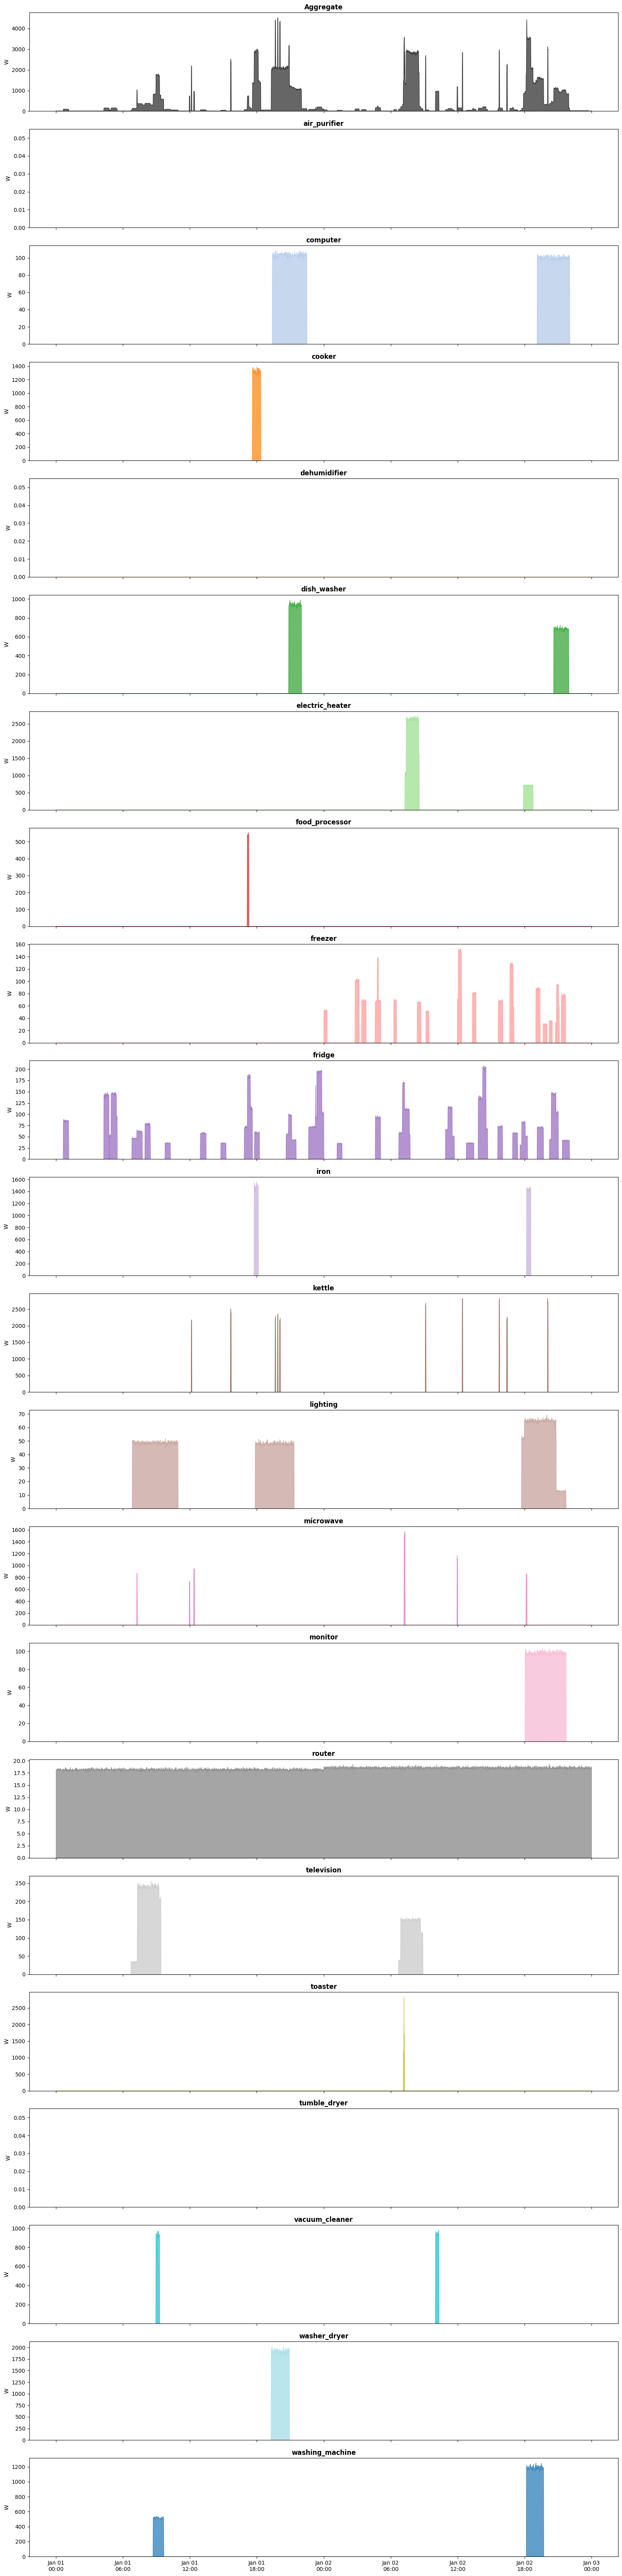

✅ Plot saved to /content/drive/MyDrive/SynthNILM_Dataset/house_001_plot.png


In [ ]:
# ============================================================
# VISUALIZE one house to confirm it looks realistic
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

hid    = 1
hpath  = f"{OUTPUT_DIR}/house_{hid:03d}"
agg    = pd.read_csv(f"{hpath}/aggregate.csv", parse_dates=['timestamp'])

# Load all appliance channels
app_files = [f for f in os.listdir(hpath)
             if f.endswith('.csv') and f != 'aggregate.csv']
channels = {}
for f in app_files:
    name = f.replace('.csv','')
    df   = pd.read_csv(f"{hpath}/{f}", parse_dates=['timestamp'])
    if df['power_W'].mean() > 1.0:  # only show active ones
        channels[name] = df

# Plot 2 days only for clarity
two_days = agg[agg['timestamp'] < agg['timestamp'].iloc[0] + pd.Timedelta(days=2)]

fig, axes = plt.subplots(len(channels) + 1, 1,
                          figsize=(16, 3 * (len(channels) + 1)),
                          sharex=True)

# Aggregate
axes[0].fill_between(two_days['timestamp'], two_days['power_W'],
                     alpha=0.6, color='black')
axes[0].set_ylabel('W')
axes[0].set_title('Aggregate', fontweight='bold')
axes[0].set_ylim(bottom=0)

# Per appliance
colors = plt.cm.tab20.colors
for idx, (app, df) in enumerate(sorted(channels.items())):
    ax     = axes[idx + 1]
    subset = df[df['timestamp'] < df['timestamp'].iloc[0] + pd.Timedelta(days=2)]
    ax.fill_between(subset['timestamp'], subset['power_W'],
                    alpha=0.7, color=colors[idx % 20])
    ax.set_ylabel('W')
    ax.set_title(app, fontweight='bold')
    ax.set_ylim(bottom=0)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/house_{hid:03d}_plot.png",
            dpi=120, bbox_inches='tight')
plt.show()
print(f"✅ Plot saved to {OUTPUT_DIR}/house_{hid:03d}_plot.png")

**100 houses**

In [ ]:
# ============================================================
# SCALE UP — Generate 100-house research dataset
# ============================================================

import shutil, os

# Remove test dataset
OLD = '/content/drive/MyDrive/SynthNILM_Dataset'
if os.path.exists(OLD):
    shutil.rmtree(OLD)

OUTPUT_DIR = '/content/drive/MyDrive/SynthNILM_Dataset_v1'

metadata = generate_dataset(
    n_houses   = 100,
    n_days     = 30,       # 1 month per house
    output_dir = OUTPUT_DIR,
    seed       = 42,
    profile_mix= {
        'working_family':      0.40,
        'student':             0.20,
        'retired':             0.25,
        'single_professional': 0.15,
    }
)

# Final stats
import numpy as np
means = []
for m in metadata:
    hid  = m['house_id']
    agg  = pd.read_csv(f"{OUTPUT_DIR}/house_{hid:03d}/aggregate.csv")
    means.append(agg['power_W'].mean())

print(f"\n=== Dataset Statistics ===")
print(f"  Houses        : 100")
print(f"  Days/house    : 30")
print(f"  Total minutes : {100 * 30 * 1440:,}")
print(f"  Avg power     : {np.mean(means):.1f}W")
print(f"  Min house avg : {np.min(means):.1f}W")
print(f"  Max house avg : {np.max(means):.1f}W")
print(f"\n✅ Saved to: {OUTPUT_DIR}")

Generating 100 houses × 30 days...

  ✅ House   1  profile=working_family         appliances=23  agg_mean= 471.0W
  ✅ House   2  profile=retired                appliances=14  agg_mean= 380.7W
  ✅ House   3  profile=single_professional    appliances=13  agg_mean= 186.3W
  ✅ House   4  profile=retired                appliances=15  agg_mean= 450.8W
  ✅ House   5  profile=working_family         appliances=22  agg_mean= 410.8W
  ✅ House   6  profile=working_family         appliances=24  agg_mean= 409.2W
  ✅ House   7  profile=working_family         appliances=19  agg_mean= 292.6W
  ✅ House   8  profile=student                appliances=11  agg_mean= 153.0W
  ✅ House   9  profile=retired                appliances=18  agg_mean= 528.7W
  ✅ House  10  profile=retired                appliances=15  agg_mean= 483.0W
  ✅ House  11  profile=retired                appliances=16  agg_mean= 448.2W
  ✅ House  12  profile=student                appliances=11  agg_mean= 154.2W
  ✅ House  13  profile=worki

In [ ]:
# ============================================================
# DETAILED DATASET REPORT — What each house contains
# ============================================================

import json
import pandas as pd
import numpy as np
import os

OUTPUT_DIR = '/content/drive/MyDrive/SynthNILM_Dataset_v1'

# Load metadata
with open(f"{OUTPUT_DIR}/dataset_metadata.json", 'r') as f:
    meta = json.load(f)

print("=" * 90)
print("  COMPLETE DATASET INVENTORY — 100 Houses")
print("=" * 90)
print(f"\n{'House':<8} {'Profile':<22} {'Apps':>4}  {'Appliances'}")
print("-" * 90)

for h in meta['houses']:
    hid   = h['house_id']
    prof  = h['profile']
    apps  = sorted(h['appliances'])
    n     = len(apps)

    # Read aggregate stats
    agg_path = f"{OUTPUT_DIR}/house_{hid:03d}/aggregate.csv"
    agg      = pd.read_csv(agg_path)
    avg_w    = agg['power_W'].mean()

    # Print house header
    print(f"\n  House {hid:>3}  {prof:<22} {n:>3} apps  avg={avg_w:.0f}W")

    # Print appliances in rows of 5
    for i in range(0, len(apps), 5):
        row = apps[i:i+5]
        print(f"           {', '.join(row)}")

print("\n" + "=" * 90)

  COMPLETE DATASET INVENTORY — 100 Houses

House    Profile                Apps  Appliances
------------------------------------------------------------------------------------------

  House   1  working_family          23 apps  avg=471W
           air_purifier, computer, cooker, dehumidifier, dish_washer
           electric_heater, food_processor, freezer, fridge, iron
           kettle, lighting, microwave, mobile_charger, monitor
           router, stereo, television, toaster, tumble_dryer
           vacuum_cleaner, washer_dryer, washing_machine

  House   2  retired                 14 apps  avg=381W
           breadmaker, cooker, dish_washer, fridge, iron
           kettle, lighting, microwave, radio, router
           stereo, television, vacuum_cleaner, washing_machine

  House   3  single_professional     13 apps  avg=186W
           air_purifier, dish_washer, electric_heater, fridge, kettle
           laptop, lighting, microwave, mobile_charger, router
           tablet_compute

In [ ]:
# ============================================================
# FIX: Recompute counters then show profile breakdown + save
# ============================================================

from collections import Counter
import pandas as pd
import numpy as np
import json
import os

OUTPUT_DIR = '/content/drive/MyDrive/SynthNILM_Dataset_v1'

with open(f"{OUTPUT_DIR}/dataset_metadata.json", 'r') as f:
    meta = json.load(f)

# Recompute all counters
all_apps            = []
profile_app_counts  = {}
profile_house_counts= Counter(h['profile'] for h in meta['houses'])

for h in meta['houses']:
    all_apps.extend(h['appliances'])
    prof = h['profile']
    if prof not in profile_app_counts:
        profile_app_counts[prof] = Counter()
    profile_app_counts[prof].update(h['appliances'])

app_counts   = Counter(all_apps)
total_houses = len(meta['houses'])

# ── Appliance frequency ──────────────────────────────────────
print("=" * 65)
print("  APPLIANCE FREQUENCY ACROSS 100 HOUSES")
print("=" * 65)
print(f"\n{'Appliance':<28} {'Houses':>6}  {'%':>5}  Bar")
print("-" * 65)
for app, count in sorted(app_counts.items(), key=lambda x: -x[1]):
    pct = count / total_houses * 100
    bar = '█' * int(pct / 3)
    print(f"  {app:<26} {count:>5}x  {pct:>4.0f}%  {bar}")

# ── Profile breakdown ────────────────────────────────────────
print("\n" + "=" * 65)
print("  APPLIANCE FREQUENCY BY PROFILE")
print("=" * 65)
for profile, counter in sorted(profile_app_counts.items()):
    n_houses = profile_house_counts[profile]
    print(f"\n  {profile.upper()}  ({n_houses} houses)")
    print(f"  {'Appliance':<28} {'Houses':>6}  {'%':>5}")
    print(f"  {'-'*45}")
    for app, count in sorted(counter.items(), key=lambda x: -x[1]):
        pct = count / n_houses * 100
        print(f"  {app:<28} {count:>5}x  {pct:>4.0f}%")

# ── Save CSV inventory ───────────────────────────────────────
rows = []
for h in meta['houses']:
    hid  = h['house_id']
    agg  = pd.read_csv(f"{OUTPUT_DIR}/house_{hid:03d}/aggregate.csv")
    row  = {
        'house_id':      hid,
        'profile':       h['profile'],
        'n_appliances':  len(h['appliances']),
        'avg_power_W':   round(agg['power_W'].mean(), 1),
        'max_power_W':   round(agg['power_W'].max(),  1),
        'n_days':        h['n_days'],
    }
    for app in sorted(app_counts.keys()):
        row[app] = 1 if app in h['appliances'] else 0
    rows.append(row)

report_df   = pd.DataFrame(rows)
report_path = f"{OUTPUT_DIR}/dataset_inventory.csv"
report_df.to_csv(report_path, index=False)

# ── Final summary ─────────────────────────────────────────────
print("\n" + "=" * 65)
print("  DATASET SUMMARY")
print("=" * 65)
print(f"  Total houses              : {len(rows)}")
print(f"  Days per house            : {meta['n_days']}")
print(f"  Total minutes             : {len(rows)*meta['n_days']*1440:,}")
print(f"  Sample rate               : 1 minute")
print(f"  Unique appliance types    : {len(app_counts)}")
print(f"  Avg appliances per house  : {report_df['n_appliances'].mean():.1f}")
print(f"  Avg aggregate power       : {report_df['avg_power_W'].mean():.1f} W")
print(f"  Min house avg power       : {report_df['avg_power_W'].min():.1f} W")
print(f"  Max house avg power       : {report_df['avg_power_W'].max():.1f} W")
print(f"\n  Profile distribution:")
for prof, count in sorted(profile_house_counts.items()):
    print(f"    {prof:<25} {count:>3} houses")
print(f"\n  Top 10 most common appliances:")
for app, count in list(sorted(app_counts.items(), key=lambda x: -x[1]))[:10]:
    print(f"    {app:<28} {count:>3}/100 houses")
print(f"\n✅ Inventory CSV saved : {report_path}")
print(f"✅ Shape               : {report_df.shape}")

  APPLIANCE FREQUENCY ACROSS 100 HOUSES

Appliance                    Houses      %  Bar
-----------------------------------------------------------------
  fridge                       100x   100%  █████████████████████████████████
  lighting                     100x   100%  █████████████████████████████████
  kettle                        97x    97%  ████████████████████████████████
  television                    90x    90%  ██████████████████████████████
  microwave                     86x    86%  ████████████████████████████
  router                        86x    86%  ████████████████████████████
  washing_machine               82x    82%  ███████████████████████████
  iron                          77x    77%  █████████████████████████
  hair_dryer                    75x    75%  █████████████████████████
  mobile_charger                74x    74%  ████████████████████████
  vacuum_cleaner                64x    64%  █████████████████████
  laptop                        62x    62%  

In [ ]:
# ============================================================
# DETAILED DATASET REPORT — What each house contains
# ============================================================

import json
import pandas as pd
import numpy as np
import os

OUTPUT_DIR = '/content/drive/MyDrive/SynthNILM_Dataset_v1'

# Load metadata
with open(f"{OUTPUT_DIR}/dataset_metadata.json", 'r') as f:
    meta = json.load(f)

print("=" * 90)
print("  COMPLETE DATASET INVENTORY — 100 Houses")
print("=" * 90)
print(f"\n{'House':<8} {'Profile':<22} {'Apps':>4}  {'Appliances'}")
print("-" * 90)

for h in meta['houses']:
    hid   = h['house_id']
    prof  = h['profile']
    apps  = sorted(h['appliances'])
    n     = len(apps)

    # Read aggregate stats
    agg_path = f"{OUTPUT_DIR}/house_{hid:03d}/aggregate.csv"
    agg      = pd.read_csv(agg_path)
    avg_w    = agg['power_W'].mean()

    # Print house header
    print(f"\n  House {hid:>3}  {prof:<22} {n:>3} apps  avg={avg_w:.0f}W")

    # Print appliances in rows of 5
    for i in range(0, len(apps), 5):
        row = apps[i:i+5]
        print(f"           {', '.join(row)}")

print("\n" + "=" * 90)

  COMPLETE DATASET INVENTORY — 100 Houses

House    Profile                Apps  Appliances
------------------------------------------------------------------------------------------

  House   1  working_family          23 apps  avg=471W
           air_purifier, computer, cooker, dehumidifier, dish_washer
           electric_heater, food_processor, freezer, fridge, iron
           kettle, lighting, microwave, mobile_charger, monitor
           router, stereo, television, toaster, tumble_dryer
           vacuum_cleaner, washer_dryer, washing_machine

  House   2  retired                 14 apps  avg=381W
           breadmaker, cooker, dish_washer, fridge, iron
           kettle, lighting, microwave, radio, router
           stereo, television, vacuum_cleaner, washing_machine

  House   3  single_professional     13 apps  avg=186W
           air_purifier, dish_washer, electric_heater, fridge, kettle
           laptop, lighting, microwave, mobile_charger, router
           tablet_compute

**Validation **

In [ ]:
# ============================================================
# PHASE 4 — VALIDATION
# Compare synthetic dataset against real REDD + UK-DALE
# ============================================================

import numpy as np
import pandas as pd
import json
import os
from scipy import stats

OUTPUT_DIR   = '/content/drive/MyDrive/SynthNILM_Dataset_v1'
UKDALE_PATH  = '/content/drive/MyDrive/Dictionary Learning Khodayar/ukdale.h5'
LIBRARY_PATH = '/content/drive/MyDrive/device_signature_library_FIXED.json'

with open(f"{OUTPUT_DIR}/dataset_metadata.json", 'r') as f:
    meta = json.load(f)

with open(LIBRARY_PATH, 'r') as f:
    device_library = json.load(f)

print("✅ All files loaded")
print(f"   Synthetic : 100 houses × 30 days")
print(f"   UK-DALE   : {UKDALE_PATH}")

✅ All files loaded
   Synthetic : 100 houses × 30 days
   UK-DALE   : /content/drive/MyDrive/Dictionary Learning Khodayar/ukdale.h5


In [ ]:
# ============================================================
# PHASE 5 — EXPORT TO HDF5 (Fixed)
# ============================================================

import subprocess
subprocess.run(['pip', 'install', 'tables', '-q'])

import numpy as np
import pandas as pd
import json
import os

OUTPUT_DIR = '/content/drive/MyDrive/SynthNILM_Dataset_v1'
HDF5_PATH  = '/content/drive/MyDrive/SynthNILM_Dataset_v1/synthnilm_v2.h5'

with open(f"{OUTPUT_DIR}/dataset_metadata.json", 'r') as f:
    meta = json.load(f)

print(f"Exporting {meta['n_houses']} houses to HDF5...\n")

with pd.HDFStore(HDF5_PATH, 'w', complevel=5, complib='zlib') as store:
    for h in meta['houses']:
        hid      = h['house_id']
        hpath    = f"{OUTPUT_DIR}/house_{hid:03d}"
        building = f"building{hid}"

        # ── Aggregate → meter1 ───────────────────────────────
        agg = pd.read_csv(f"{hpath}/aggregate.csv",
                          parse_dates=['timestamp'])
        agg = agg.set_index('timestamp')
        agg.index = pd.DatetimeIndex(agg.index)
        agg.columns = pd.MultiIndex.from_tuples(
            [('power', 'active')],
            names=['physical_quantity', 'type']
        )
        store.put(f'/{building}/elec/meter1', agg, format='table')

        # ── Appliances → meter2, meter3, ... ─────────────────
        app_files = sorted([
            f for f in os.listdir(hpath)
            if f.endswith('.csv') and f != 'aggregate.csv'
        ])
        for meter_idx, app_file in enumerate(app_files, start=2):
            df = pd.read_csv(f"{hpath}/{app_file}",
                             parse_dates=['timestamp'])
            df = df.set_index('timestamp')
            df.index = pd.DatetimeIndex(df.index)
            df.columns = pd.MultiIndex.from_tuples(
                [('power', 'active')],
                names=['physical_quantity', 'type']
            )
            store.put(f'/{building}/elec/meter{meter_idx}',
                      df, format='table')

        n_meters = len(app_files) + 1
        print(f"  ✅ Building {hid:>3}  {h['profile']:<22}  "
              f"{n_meters} meters")

size_gb = os.path.getsize(HDF5_PATH) / 1e9
print(f"\n✅ HDF5 export complete!")
print(f"   Path : {HDF5_PATH}")
print(f"   Size : {size_gb:.2f} GB")

Exporting 100 houses to HDF5...

  ✅ Building   1  working_family          22 meters
  ✅ Building   2  retired                 15 meters
  ✅ Building   3  single_professional     17 meters
  ✅ Building   4  retired                 16 meters
  ✅ Building   5  working_family          21 meters
  ✅ Building   6  working_family          23 meters
  ✅ Building   7  working_family          18 meters
  ✅ Building   8  student                 12 meters
  ✅ Building   9  retired                 21 meters
  ✅ Building  10  retired                 13 meters
  ✅ Building  11  retired                 21 meters
  ✅ Building  12  student                 11 meters
  ✅ Building  13  working_family          22 meters
  ✅ Building  14  single_professional     15 meters
  ✅ Building  15  working_family          22 meters
  ✅ Building  16  working_family          25 meters
  ✅ Building  17  single_professional     17 meters
  ✅ Building  18  working_family          25 meters
  ✅ Building  19  retired      